# Experiment multi-asset: BTC vs GLD vs USO

Aquest notebook reformula el problema com una tasca d'assignació dinàmica d'actius.

L'agent decideix quin actiu mantenir en cada pas temporal:

- `0 = BTC`
- `1 = GLD`
- `2 = USO`

In [ ]:
import sys
from pathlib import Path

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from env.trading_env_multi_asset_no_leakage import TradingEnv
from stable_baselines3 import PPO

## 1. Configuració de l'experiment

In [2]:
EXPERIMENT_NAME = "multi_asset_btc_gld_uso"
ACTION_TYPE = "asset_allocation"
TRANSACTION_COST = 0.001
TOTAL_TIMESTEPS = 50000
TRAIN_SPLIT = 0.8

print("Experiment:", EXPERIMENT_NAME)
print("Action type:", ACTION_TYPE)
print("Transaction cost:", TRANSACTION_COST)
print("Timesteps:", TOTAL_TIMESTEPS)
print("Train split:", TRAIN_SPLIT)

Experiment: multi_asset_btc_gld_uso
Action type: asset_allocation
Transaction cost: 0.001
Timesteps: 50000
Train split: 0.8


## 2. Descàrrega de dades

In [3]:
btc = yf.download("BTC-USD", period="730d", interval="1h", auto_adjust=False)
gld = yf.download("GLD", period="730d", interval="1h", auto_adjust=False)
uso = yf.download("USO", period="730d", interval="1h", auto_adjust=False)

print("BTC shape:", btc.shape)
print("GLD shape:", gld.shape)
print("USO shape:", uso.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

BTC shape: (17357, 6)
GLD shape: (5077, 6)
USO shape: (5078, 6)


## 3. Neteja de columnes

In [4]:
btc.columns = btc.columns.get_level_values(0)
gld.columns = gld.columns.get_level_values(0)
uso.columns = uso.columns.get_level_values(0)

btc.columns.name = None
gld.columns.name = None
uso.columns.name = None

print(btc.columns)
print(gld.columns)
print(uso.columns)

btc.head(), gld.head(), uso.head()

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


(                              Adj Close         Close          High  \
 Datetime                                                              
 2024-04-27 00:00:00+00:00  62937.859375  62937.859375  63894.988281   
 2024-04-27 01:00:00+00:00  62559.429688  62559.429688  63217.339844   
 2024-04-27 02:00:00+00:00  62934.085938  62934.085938  63265.148438   
 2024-04-27 03:00:00+00:00  63071.062500  63071.062500  63125.246094   
 2024-04-27 04:00:00+00:00  62996.097656  62996.097656  63115.500000   
 
                                     Low          Open     Volume  
 Datetime                                                          
 2024-04-27 00:00:00+00:00  62852.578125  63753.121094          0  
 2024-04-27 01:00:00+00:00  62517.667969  63134.039062  580343808  
 2024-04-27 02:00:00+00:00  62509.085938  62581.515625  270473216  
 2024-04-27 03:00:00+00:00  62858.570312  62927.632812          0  
 2024-04-27 04:00:00+00:00  62939.726562  63065.574219          0  ,
                 

## 4. Normalització temporal i sincronització

In [5]:
btc_1h = btc[["Close"]].copy()
gld_1h = gld[["Close"]].copy()
uso_1h = uso[["Close"]].copy()

btc_1h.index = btc_1h.index.floor("1h")
gld_1h.index = gld_1h.index.floor("1h")
uso_1h.index = uso_1h.index.floor("1h")

btc_1h = btc_1h.rename(columns={"Close": "btc_close"})
gld_1h = gld_1h.rename(columns={"Close": "gld_close"})
uso_1h = uso_1h.rename(columns={"Close": "uso_close"})

print(btc_1h.head())
print(gld_1h.head())
print(uso_1h.head())

                              btc_close
Datetime                               
2024-04-27 00:00:00+00:00  62937.859375
2024-04-27 01:00:00+00:00  62559.429688
2024-04-27 02:00:00+00:00  62934.085938
2024-04-27 03:00:00+00:00  63071.062500
2024-04-27 04:00:00+00:00  62996.097656
                            gld_close
Datetime                             
2023-05-26 13:00:00+00:00  180.960007
2023-05-26 14:00:00+00:00  180.419998
2023-05-26 15:00:00+00:00  180.740005
2023-05-26 16:00:00+00:00  180.600006
2023-05-26 17:00:00+00:00  180.789993
                           uso_close
Datetime                            
2023-05-26 13:00:00+00:00  64.769997
2023-05-26 14:00:00+00:00  64.739998
2023-05-26 15:00:00+00:00  64.739998
2023-05-26 16:00:00+00:00  64.529999
2023-05-26 17:00:00+00:00  64.730003


In [6]:
common_index = btc_1h.index.intersection(gld_1h.index).intersection(uso_1h.index)

btc_sync = btc_1h.loc[common_index].copy()
gld_sync = gld_1h.loc[common_index].copy()
uso_sync = uso_1h.loc[common_index].copy()

print("BTC sync shape:", btc_sync.shape)
print("GLD sync shape:", gld_sync.shape)
print("USO sync shape:", uso_sync.shape)
print("Start:", common_index.min())
print("End:", common_index.max())

BTC sync shape: (3440, 1)
GLD sync shape: (3440, 1)
USO sync shape: (3440, 1)
Start: 2024-04-29 13:00:00+00:00
End: 2026-04-24 19:00:00+00:00


In [7]:
df = btc_sync.join(gld_sync, how="inner").join(uso_sync, how="inner")

print("Merged shape:", df.shape)
df.head()

Merged shape: (3440, 3)


,btc_close,gld_close,uso_close
Datetime,,,
2024-04-29 13:00:00+00:00,61974.937500,216.470001,79.794998
2024-04-29 14:00:00+00:00,62847.734375,216.360001,79.370003
2024-04-29 15:00:00+00:00,62991.269531,216.929993,79.868797
2024-04-29 16:00:00+00:00,62789.363281,217.130005,79.510002
2024-04-29 17:00:00+00:00,63042.710938,216.440002,79.419998


## 5. Creació de retorns i agregació a 4 hores

In [8]:
df["btc_ret_1h"] = df["btc_close"].pct_change()
df["gld_ret_1h"] = df["gld_close"].pct_change()
df["uso_ret_1h"] = df["uso_close"].pct_change()

df = df.dropna().copy()

df.head()

,btc_close,gld_close,uso_close,btc_ret_1h,gld_ret_1h,uso_ret_1h
Datetime,,,,,,
2024-04-29 14:00:00+00:00,62847.734375,216.360001,79.370003,0.014083,-0.000508,-0.005326
2024-04-29 15:00:00+00:00,62991.269531,216.929993,79.868797,0.002284,0.002634,0.006284
2024-04-29 16:00:00+00:00,62789.363281,217.130005,79.510002,-0.003205,0.000922,-0.004492
2024-04-29 17:00:00+00:00,63042.710938,216.440002,79.419998,0.004035,-0.003178,-0.001132
2024-04-29 18:00:00+00:00,62845.902344,216.179993,79.500000,-0.003122,-0.001201,0.001007


In [9]:
df_4h = df.resample("4h").agg({
    "btc_close": "last",
    "gld_close": "last",
    "uso_close": "last",
    "btc_ret_1h": "sum",
    "gld_ret_1h": "sum",
    "uso_ret_1h": "sum",
}).dropna().copy()

print("4H shape:", df_4h.shape)
df_4h.head()

4H shape: (1149, 6)


,btc_close,gld_close,uso_close,btc_ret_1h,gld_ret_1h,uso_ret_1h
Datetime,,,,,,
2024-04-29 12:00:00+00:00,62991.269531,216.929993,79.868797,0.016367,0.002126,0.000958
2024-04-29 16:00:00+00:00,62862.511719,216.169998,79.470001,-0.002028,-0.003503,-0.004994
2024-04-30 12:00:00+00:00,60787.402344,212.737396,78.639999,-0.032995,-0.015897,-0.010253
2024-04-30 16:00:00+00:00,59120.066406,211.970001,78.379997,-0.027629,-0.003608,-0.003304
2024-05-01 12:00:00+00:00,56792.820312,213.410004,76.339996,-0.039570,0.006795,-0.026177


## 6. Feature engineering

In [ ]:
# Target returns: retorns que s'utilitzen per calcular la recompensa
df_4h["btc_target_ret"] = df_4h["btc_close"].pct_change()
df_4h["gld_target_ret"] = df_4h["gld_close"].pct_change()
df_4h["uso_target_ret"] = df_4h["uso_close"].pct_change()

# Features: informació passada disponible per l'agent
df_4h["btc_ret_4h"] = df_4h["btc_target_ret"].shift(1)
df_4h["gld_ret_4h"] = df_4h["gld_target_ret"].shift(1)
df_4h["uso_ret_4h"] = df_4h["uso_target_ret"].shift(1)

df_4h["btc_vol_12"] = df_4h["btc_target_ret"].rolling(12).std().shift(1)
df_4h["gld_vol_12"] = df_4h["gld_target_ret"].rolling(12).std().shift(1)
df_4h["uso_vol_12"] = df_4h["uso_target_ret"].rolling(12).std().shift(1)

df_4h = df_4h.dropna().copy()

print("Final 4H shape:", df_4h.shape)
df_4h.head()

Final 4H shape: (1136, 15)


,btc_close,gld_close,uso_close,btc_ret_1h,gld_ret_1h,uso_ret_1h,btc_target_ret,gld_target_ret,uso_target_ret,btc_ret_4h,gld_ret_4h,uso_ret_4h,btc_vol_12,gld_vol_12,uso_vol_12
Datetime,,,,,,,,,,,,,,,
2024-05-07 16:00:00+00:00,62989.285156,214.214996,75.489998,-0.011587,-0.000396,-0.004069,-0.011538,-0.000397,-0.004090,0.008434,-0.004043,0.001983,0.026712,0.006463,0.008833
2024-05-08 12:00:00+00:00,62276.804688,214.600006,75.730003,-0.011303,0.001796,0.003250,-0.011311,0.001797,0.003179,-0.011538,-0.000397,-0.004090,0.026959,0.006415,0.008830
2024-05-08 16:00:00+00:00,62233.468750,213.589996,76.129997,-0.000680,-0.004714,0.005277,-0.000696,-0.004706,0.005282,-0.011311,0.001797,0.003179,0.025176,0.004305,0.008835
2024-05-09 12:00:00+00:00,62121.359375,215.968994,76.285004,-0.001573,0.011144,0.002056,-0.001801,0.011138,0.002036,-0.000696,-0.004706,0.005282,0.023427,0.004416,0.009159
2024-05-09 16:00:00+00:00,62414.937500,216.940002,76.540001,0.004734,0.004491,0.003346,0.004726,0.004496,0.003343,-0.001801,0.011138,0.002036,0.019146,0.005092,0.005375


## 7. Dataset de l'entorn multi-asset

In [ ]:
feature_columns = [
    "btc_ret_4h",
    "btc_vol_12",
    "gld_ret_4h",
    "gld_vol_12",
    "uso_ret_4h",
    "uso_vol_12",
]

target_columns = [
    "btc_target_ret",
    "gld_target_ret",
    "uso_target_ret",
]

env_df = df_4h[feature_columns + target_columns].copy()

print(env_df.shape)
env_df.head()

(1136, 9)


,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12,uso_ret_4h,uso_vol_12,btc_target_ret,gld_target_ret,uso_target_ret
Datetime,,,,,,,,,
2024-05-07 16:00:00+00:00,0.008434,0.026712,-0.004043,0.006463,0.001983,0.008833,-0.011538,-0.000397,-0.004090
2024-05-08 12:00:00+00:00,-0.011538,0.026959,-0.000397,0.006415,-0.004090,0.008830,-0.011311,0.001797,0.003179
2024-05-08 16:00:00+00:00,-0.011311,0.025176,0.001797,0.004305,0.003179,0.008835,-0.000696,-0.004706,0.005282
2024-05-09 12:00:00+00:00,-0.000696,0.023427,-0.004706,0.004416,0.005282,0.009159,-0.001801,0.011138,0.002036
2024-05-09 16:00:00+00:00,-0.001801,0.019146,0.011138,0.005092,0.002036,0.005375,0.004726,0.004496,0.003343


## 8. Split train/test temporal

In [12]:
split_idx = int(len(env_df) * TRAIN_SPLIT)

train_data = env_df.iloc[:split_idx].copy()
test_data = env_df.iloc[split_idx:].copy()

print("train_data:", train_data.shape)
print("test_data:", test_data.shape)

train_data: (908, 9)
test_data: (228, 9)


## 9. Creació dels entorns

In [ ]:
env_train_multi = TradingEnv(
    data=train_data,
    feature_columns=feature_columns,
    transaction_cost=TRANSACTION_COST,
)

env_test_multi = TradingEnv(
    data=test_data,
    feature_columns=feature_columns,
    transaction_cost=TRANSACTION_COST,
)

obs, info = env_train_multi.reset()
print("Initial observation:", obs)
print("Observation shape:", obs.shape)
print("Info:", info)

Initial observation: [ 0.00843361  0.02671173 -0.00404329  0.00646271  0.00198284  0.00883261
  0.        ]
Observation shape: (7,)
Info: {}


## 10. Entrenament PPO

In [14]:
model_multi = PPO(
    "MlpPolicy",
    env_train_multi,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_multi.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 971 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 747           |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00032177148 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.1          |
|    explained_variance   | -1.19         |
|    learning_rate        | 0.0003        |
|    loss                 | -0.0109       |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000736     |

## 11. Funcions d'avaluació

In [15]:
def evaluate_model_multi_asset(model, env, data_df):
    obs, info = env.reset()

    done = False
    truncated = False

    equity = [1.0]
    rewards = []
    actions = []
    assets = []

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(int(action))

        rewards.append(reward)
        actions.append(int(action))
        assets.append(info["asset"])

        equity.append(equity[-1] * (1.0 + reward))

    results = pd.DataFrame({
        "reward": rewards,
        "action": actions,
        "asset": assets,
    }, index=data_df.index[1:1+len(rewards)])

    results["equity"] = equity[1:]
    return results


def compute_metrics_multi_asset(results_df, periods_per_year=252*2):
    rets = results_df["reward"].dropna()

    cumulative_return = (1 + rets).prod() - 1

    mean_ret = rets.mean()
    vol = rets.std()

    sharpe = np.nan
    if vol > 1e-8:
        sharpe = (mean_ret / vol) * np.sqrt(periods_per_year)

    downside = rets[rets < 0].std()
    sortino = np.nan
    if downside > 1e-8:
        sortino = (mean_ret / downside) * np.sqrt(periods_per_year)

    equity = results_df["equity"]
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    asset_changes = results_df["asset"].diff().fillna(0)
    n_switches = int((asset_changes != 0).sum())

    return {
        "cumulative_return": cumulative_return,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_drawdown,
        "n_switches": n_switches,
    }

## 12. Avaluació del model

In [16]:
results_multi = evaluate_model_multi_asset(model_multi, env_test_multi, test_data)

results_multi.head()

,reward,action,asset,equity
Datetime,,,,
2025-12-17 20:00:00+00:00,0.016827,2,2,1.016827
2025-12-18 12:00:00+00:00,0.005195,2,2,1.022110
2025-12-18 16:00:00+00:00,0.003692,2,2,1.025883
2025-12-18 20:00:00+00:00,0.029868,0,0,1.056524
2025-12-19 12:00:00+00:00,-0.008899,2,2,1.047122


In [17]:
metrics_multi = compute_metrics_multi_asset(results_multi)

comparison_multi = pd.DataFrame(
    [metrics_multi],
    index=["MultiAsset_BTC_GLD_USO"]
)

comparison_multi

,cumulative_return,sharpe,sortino,max_drawdown,n_switches
MultiAsset_BTC_GLD_USO,12.081196,13.472475,30.580806,-0.057498,94


## 13. Benchmarks buy-and-hold

In [18]:
btc_bh = (1 + test_data["btc_ret_4h"]).prod() - 1
gld_bh = (1 + test_data["gld_ret_4h"]).prod() - 1
uso_bh = (1 + test_data["uso_ret_4h"]).prod() - 1

benchmarks = pd.DataFrame(
    [{
        "BTC Buy & Hold": btc_bh,
        "GLD Buy & Hold": gld_bh,
        "USO Buy & Hold": uso_bh,
    }]
)

benchmarks

,BTC Buy & Hold,GLD Buy & Hold,USO Buy & Hold
0,-0.109358,0.095858,0.98459


## 14. Distribució d'accions i actius

In [19]:
print("Actions:")
print(results_multi["action"].value_counts())

print("\nAssets:")
print(results_multi["asset"].value_counts())

Actions:
action
2    137
0     90
Name: count, dtype: int64

Assets:
asset
2    137
0     90
Name: count, dtype: int64


## 15. Corba d'equity

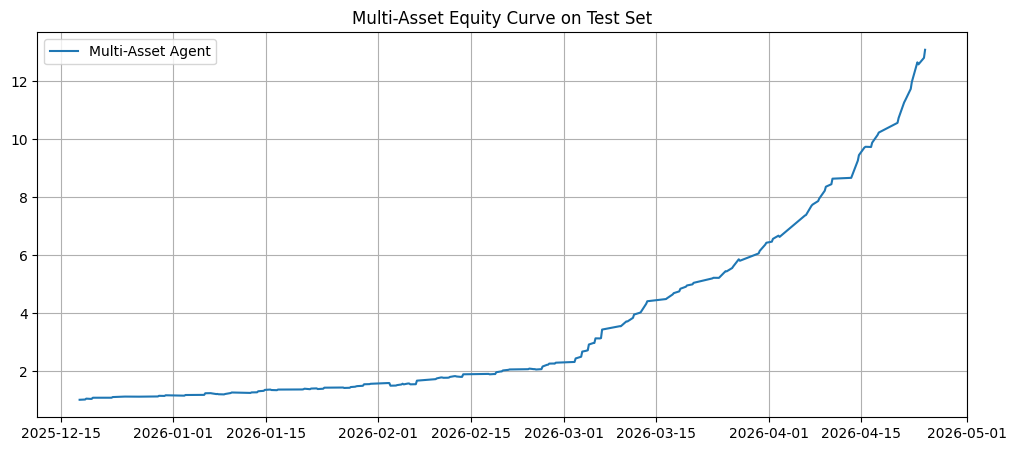

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(results_multi.index, results_multi["equity"], label="Multi-Asset Agent")
plt.title("Multi-Asset Equity Curve on Test Set")
plt.legend()
plt.grid(True)
plt.show()

## 16. Comparació visual amb buy-and-hold dels actius

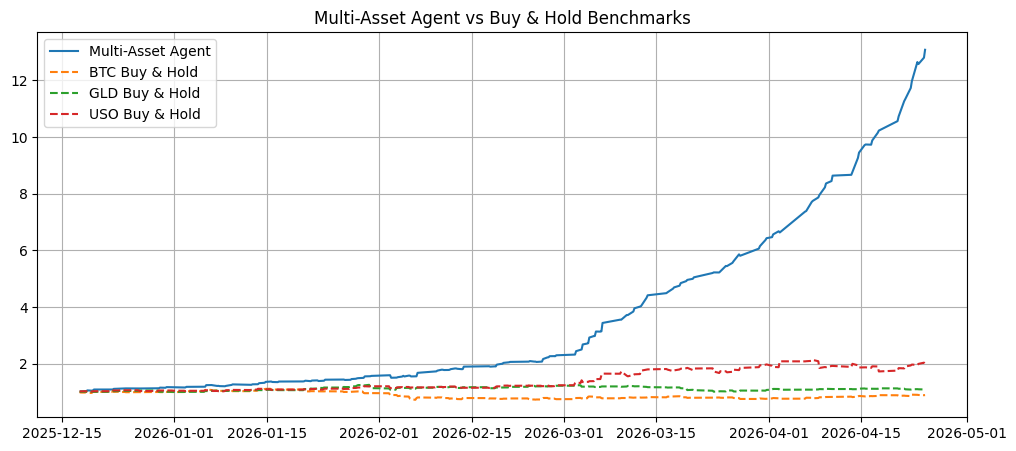

In [21]:
bh_curves = pd.DataFrame(index=test_data.index)
bh_curves["BTC_BH"] = (1 + test_data["btc_ret_4h"]).cumprod()
bh_curves["GLD_BH"] = (1 + test_data["gld_ret_4h"]).cumprod()
bh_curves["USO_BH"] = (1 + test_data["uso_ret_4h"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(results_multi.index, results_multi["equity"], label="Multi-Asset Agent")
plt.plot(bh_curves.index, bh_curves["BTC_BH"], label="BTC Buy & Hold", linestyle="--")
plt.plot(bh_curves.index, bh_curves["GLD_BH"], label="GLD Buy & Hold", linestyle="--")
plt.plot(bh_curves.index, bh_curves["USO_BH"], label="USO Buy & Hold", linestyle="--")
plt.title("Multi-Asset Agent vs Buy & Hold Benchmarks")
plt.legend()
plt.grid(True)
plt.show()

## 17. Guardat de resultats

In [22]:
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

results_multi.to_csv(results_dir / "results_multi_asset_btc_gld_uso.csv")
comparison_multi.to_csv(results_dir / "comparison_multi_asset_btc_gld_uso.csv")
benchmarks.to_csv(results_dir / "benchmarks_multi_asset_btc_gld_uso.csv")

print("Results saved in:", results_dir)

Results saved in: c:\Users\rfran\OneDrive\Documentos\UOC\Master\TFM\tfm-drl-trading\results


In [23]:
np.random.seed(42)
test_data_shuffled = test_data.sample(frac=1)

env_test_random = TradingEnv(
    data=test_data_shuffled,
    feature_columns=feature_columns,
    transaction_cost=TRANSACTION_COST,
)

results_random = evaluate_model_multi_asset(model_multi, env_test_random, test_data_shuffled)

compute_metrics_multi_asset(results_random)

{'cumulative_return': np.float64(11.991051320281626),
 'sharpe': np.float64(13.48872323332893),
 'sortino': np.float64(29.75518751941211),
 'max_drawdown': np.float64(-0.05613885411075037),
 'n_switches': 88}